In [29]:
import sys
sys.path.append('../cace/')

import numpy as np
import torch
import torch.nn as nn
import logging
import datetime

import cace
from cace.representations import Cace
from cace.modules import CosineCutoff, MollifierCutoff, PolynomialCutoff
from cace.modules import BesselRBF, GaussianRBF, GaussianRBFCentered

from cace.models.atomistic import NeuralNetworkPotential
from cace.tasks.train import TrainingTask

torch.set_default_dtype(torch.float32)

cace.tools.setup_logger(level='INFO')
cutoff = 4.5

#val_ratio = float(sys.argv[1])
val_ratio = 0.1

print("reading data")
collection = cace.tasks.get_dataset_from_xyz(train_path='/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz',
                                 valid_fraction=val_ratio,
                                 seed=1,
                                 cutoff=cutoff,
                                 data_key={'energy': 'energy', 'forces':'forces'}, 
                                 atomic_energies={1: -0.1749365806299343, 8: -0.08746829031496617, 9: -4.620975436064299, 19: -4.620975436064285} # avg
                                 )
batch_size = 20

train_loader = cace.tasks.load_data_loader(collection=collection,
                              data_type='train',
                              batch_size=batch_size,
                              )

valid_loader = cace.tasks.load_data_loader(collection=collection,
                              data_type='valid',
                              batch_size=10,
                              )

reading data
2025-03-23 21:00:45.525 INFO: Loaded 200 training configurations from '/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz'
2025-03-23 21:00:45.525 INFO: Loaded 200 training configurations from '/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz'
2025-03-23 21:00:45.525 INFO: Loaded 200 training configurations from '/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz'
2025-03-23 21:00:45.525 INFO: Loaded 200 training configurations from '/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz'
2025-03-23 21:00:45.525 INFO: Loaded 200 training configurations from '/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_200.xyz'
2025-03-23 21:00:45.527 INFO: Using random 10.0% of training set for validation
2025-03-23 21:00:45.527 INFO: Using random 10.0% of training set fo

In [31]:
evaluator = cace.tasks.EvaluateTask(model_path='/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/loss_data/N_200_N_21_loss20250323_165945_model_009.pth', device='cpu',
                                    energy_key='CACE_energy', #'ewald_potential',
                                    forces_key='CACE_forces',
                                    other_keys=['q'],
                                    )#save_folder+'loss'+time_name+'_model.pth'

pred_train = evaluator(train_loader)
pred_test = evaluator(valid_loader)

print(pred_train,pred_test)

Using CPU
{'energy': array([-1.23927391e+00, -1.70825481e+00, -1.96968412e+00, -7.90523052e-01,
       -5.86613655e-01, -1.12828493e-01, -1.14214802e+00, -1.16209960e+00,
       -2.31060362e+00, -5.82760990e-01,  1.24146378e+00, -1.14644051e-01,
       -4.58251095e+00, -1.55274665e+00, -1.53021300e+00, -1.31609368e+00,
       -1.16554809e+00,  1.68440104e-01,  9.87043381e-02, -1.75016081e+00,
       -1.26790547e+00,  1.86974764e+00, -2.53799021e-01, -1.08397377e+00,
        1.23081064e+00, -6.94302559e-01, -2.96033859e-01, -7.58086205e-01,
       -5.11274338e-01,  1.65417480e+00, -7.23275542e-01,  5.93306541e-01,
        1.99023962e-01,  8.84355545e-01, -6.80230737e-01,  2.99579144e-01,
        8.27100635e-01,  6.36702299e-01, -4.91613269e-01, -1.59839749e+00,
       -5.45266628e-01, -1.28916657e+00, -1.15574884e+00,  8.28157961e-01,
       -1.60787463e-01,  4.46517706e-01, -9.51431274e-01, -1.16752219e+00,
       -1.50254798e+00,  5.65863907e-01, -5.02558804e+00, -1.00992417e+00,
    

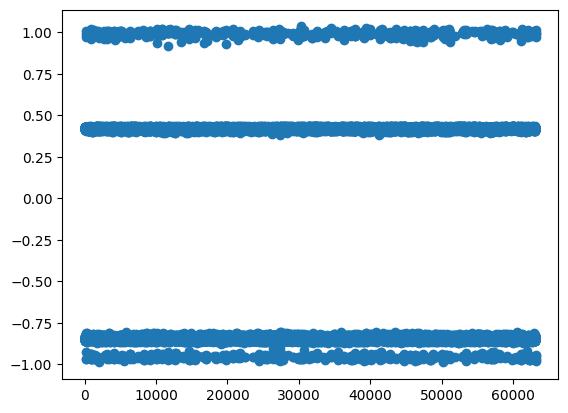

In [35]:
import matplotlib.pyplot as plt
plt.scatter(np.arange(1,pred_train['q'].shape[0]+1),-pred_train['q']/15)

In [33]:
print({stop})

NameError: name 'stop' is not defined

In [ ]:
from ase.io import read, write
import numpy as np

# 读取所有构型（假设文件路径为 'electrolyte.xyz'）
all_atoms = read('/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte.xyz', index=':')  # 读取全部 1809 个构型

# 随机选择 200 个（设置随机种子保证可重复性）
np.random.seed(42)
selected_indices = np.random.choice(len(all_atoms), size=10, replace=False)
selected_atoms = [all_atoms[i] for i in selected_indices]

# 保存选中的 200 个构型到新文件
write('/dssg/home/acct-matxzl/matxzl/Yajie/MDNN/cace-lr-fit-main/fit-electrolyte-B/electrolyte_10.xyz', selected_atoms)